Bộ đệm prioritized experience replay
Bạn sẽ giới thiệu lớp PrioritizedExperienceReplay, một cấu trúc dữ liệu mà bạn sẽ dùng sau đó để triển khai DQN với Prioritized Experience Replay.

PrioritizedExperienceReplay là một cải tiến so với lớp ExperienceReplay mà bạn đã dùng đến giờ để huấn luyện các agent DQN. Một bộ đệm prioritized experience replay đảm bảo rằng các transition được lấy mẫu từ đó có giá trị học tập cao hơn cho agent so với lấy mẫu đồng đều.

Hiện tại, hãy triển khai các phương thức .__init__(), .push(), .update_priorities(), .increase_beta() và .__len__(). Phương thức cuối cùng, .sample(), sẽ là trọng tâm của Bài tập tiếp theo.

Hướng dẫn
100 XP
Trong .push(), khởi tạo mức độ ưu tiên của transition bằng giá trị ưu tiên lớn nhất trong bộ đệm (hoặc 1 nếu bộ đệm trống).
Trong .update_priorities(), đặt mức độ ưu tiên bằng giá trị tuyệt đối của TD error tương ứng; cộng thêm self.epsilon để bao quát các trường hợp biên.
Trong .increase_beta(), tăng beta lên self.beta_increment; đảm bảo beta không vượt quá 1.

In [ ]:
class PrioritizedReplayBuffer:
    def __init__(
        self, capacity, alpha=0.6, beta=0.4, beta_increment=0.001, epsilon=0.01
    ):
        self.memory = deque(maxlen=capacity)
        self.alpha, self.beta, self.beta_increment, self.epsilon = (alpha, beta, beta_increment, epsilon)
        self.priorities = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        experience_tuple = (state, action, reward, next_state, done)
        # Initialize the transition's priority
        max_priority = ____
        self.memory.append(experience_tuple)
        self.priorities.append(max_priority)
    
    def update_priorities(self, indices, td_errors):
        for idx, td_error in zip(indices, td_errors.tolist()):
            # Update the transition's priority
            self.priorities[idx] = ____

    def increase_beta(self):
        # Increase beta if less than 1
        self.beta = ____

    def __len__(self):
        return len(self.memory)
      
buffer = PrioritizedReplayBuffer(capacity=3)
buffer.push(state=[1,3], action=2, reward=1, next_state=[2,4], done=False)
print("Transition in memory buffer:", buffer.memory)
print("Priority buffer:", buffer.priorities)

In [ ]:
"""
Có thể lấy mức độ ưu tiên lớn nhất trong bộ đệm bằng max(self.priorities).
Dùng abs(td_error.item()) để lấy giá trị tuyệt đối của TD error.
Cộng self.beta_increment vào self.beta, nhưng chỉ khi self.beta nhỏ hơn 1.



class PrioritizedReplayBuffer:
    def __init__(
        self, capacity, alpha=0.6, beta=0.4, beta_increment=0.001, epsilon=0.01
    ):
        self.memory = deque(maxlen=capacity)
        self.alpha, self.beta, self.beta_increment, self.epsilon = (alpha, beta, beta_increment, epsilon)
        self.priorities = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        experience_tuple = (state, action, reward, next_state, done)
        # Initialize the transition's priority
        max_priority = max(self.priorities) if self.memory else 1.0
        self.memory.append(experience_tuple)
        self.priorities.append(max_priority)
    
    def update_priorities(self, indices, td_errors):
        for idx, td_error in zip(indices, td_errors.tolist()):
            # Update the transition's priority
            self.priorities[idx] = abs(td_error.item()) + self.epsilon

    def increase_beta(self):
        # Increase beta if less than 1
        self.beta = min(1.0, self.beta + self.beta_increment)

    def __len__(self):
        return len(self.memory)
      
buffer = PrioritizedReplayBuffer(capacity=3)
buffer.push(state=[1,3], action=2, reward=1, next_state=[2,4], done=False)
print("Transition in memory buffer:", buffer.memory)
print("Priority buffer:", buffer.priorities)

"""


Lấy mẫu từ bộ đệm PER
Trước khi bạn có thể dùng lớp Prioritized Experience Buffer để huấn luyện agent, bạn vẫn cần triển khai phương thức .sample(). Phương thức này nhận vào kích thước mẫu bạn muốn rút và trả về các chuyển tiếp đã lấy mẫu dưới dạng tensors, kèm theo chỉ số của chúng trong bộ đệm nhớ và trọng số tầm quan trọng.

Một bộ đệm với sức chứa 10 đã được nạp sẵn trong môi trường của bạn để bạn thực hiện lấy mẫu.

Hướng dẫn
100 XP
Tính xác suất lấy mẫu tương ứng với mỗi chuyển tiếp.
Rút các chỉ số tương ứng với các chuyển tiếp trong mẫu; np.random.choice(a, s, p=p) lấy một mẫu kích thước s có hoàn lại từ mảng a, dựa trên mảng xác suất p.
Tính trọng số tầm quan trọng tương ứng với mỗi chuyển tiếp.

In [ ]:
def sample(self, batch_size):
    priorities = np.array(self.priorities)
    # Calculate the sampling probabilities
    probabilities = ____ / np.sum(____)
    # Draw the indices for the sample
    indices = np.random.choice(____)
    # Calculate the importance weights
    weights = (1 / (len(self.memory) * ____)) ** ____
    weights /= np.max(weights)
    states, actions, rewards, next_states, dones = zip(*[self.memory[idx] for idx in indices])
    weights = [weights[idx] for idx in indices]
    states_tensor = torch.tensor(states, dtype=torch.float32)
    rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
    next_states_tensor = torch.tensor(next_states, dtype=torch.float32)
    dones_tensor = torch.tensor(dones, dtype=torch.float32)
    weights_tensor = torch.tensor(weights, dtype=torch.float32)
    actions_tensor = torch.tensor(actions, dtype=torch.long).unsqueeze(1)
    return (states_tensor, actions_tensor, rewards_tensor, next_states_tensor,
            dones_tensor, indices, weights_tensor)

PrioritizedReplayBuffer.sample = sample
print("Sampled transitions:\n", buffer.sample(3))


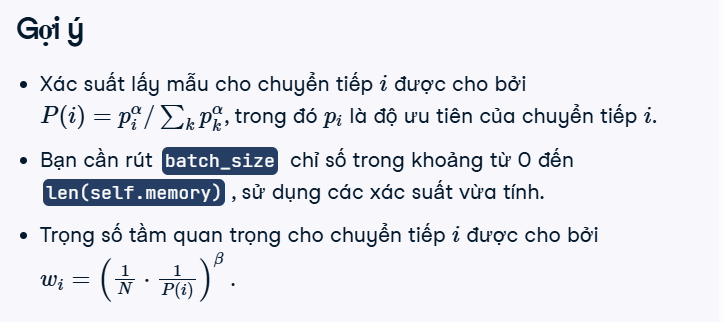

In [ ]:
"""
def sample(self, batch_size):
    priorities = np.array(self.priorities)
    # Calculate the sampling probabilities
    probabilities = priorities**self.alpha / np.sum(priorities**self.alpha)
    # Draw the indices for the sample
    indices = np.random.choice(len(self.memory), batch_size, p=probabilities)
    # Calculate the importance weights
    weights = (1 / (len(self.memory) * probabilities)) ** self.beta
    weights /= np.max(weights)
    states, actions, rewards, next_states, dones = zip(*[self.memory[idx] for idx in indices])
    weights = [weights[idx] for idx in indices]    
    print(f"Sampling {batch_size} transitions from a buffer with capacity {self.capacity}.\nPriorities: {np.round(self.priorities, 2)}\nProbabilities: {np.round(probabilities, 2)}\nSampled indices: {indices}\nWeights: {np.round(weights, 2)}")
    states_tensor = torch.tensor(states, dtype=torch.float32)
    rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
    next_states_tensor = torch.tensor(next_states, dtype=torch.float32)
    dones_tensor = torch.tensor(dones, dtype=torch.float32)
    weights_tensor = torch.tensor(weights, dtype=torch.float32)
    actions_tensor = torch.tensor(actions, dtype=torch.long).unsqueeze(1)
    return (states_tensor, actions_tensor, rewards_tensor, next_states_tensor,
            dones_tensor, indices, weights_tensor)

PrioritizedReplayBuffer.sample = sample
print("Sample a batch of 3 transitions:\n", buffer.sample(3))

"""